# Nepal Inflation & Remittance Analysis (2010–2024)

**Objective:**  
Analyze inflation trends and remittance inflows in Nepal using official data to understand economic patterns.

**Tools:** Python, Pandas, NumPy, Matplotlib  
**Data Sources:**  World Bank


In [40]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 


## Load Data


In [41]:
remittance = pd.read_csv("data/remittance.csv")
inflation = pd.read_csv("data/inflation.csv")

## Data Cleaning
Cleaning datasets by renaming rows and removing missing values.



In [42]:
nepal_inflation = inflation.iloc[0]
nepal_inflation = nepal_inflation.drop(["Series Name","Series Code","Country Code"])
nepal_inflation.dropna(inplace=True)

nepal_remittance = remittance.iloc[0]
nepal_remittance = nepal_remittance.drop(["Series Name","Series Code","Country Code"])
nepal_remittance.dropna(inplace=True)


## Merging
Merging inflation values , remittance values and years in a single dataframe.

In [43]:
years = [col for col in remittance.columns if '[YR' in col]
rem_values = nepal_remittance[years].values.flatten().astype(float)
inf_values = nepal_inflation[years].values.flatten().astype(float)

df = pd.DataFrame({
                    "Years":years ,
                    "Remittance":rem_values,
                    "Inflation":inf_values
                })
print(df)

            Years  Remittance  Inflation
0   2010 [YR2010]   21.646985   9.326504
1   2011 [YR2011]   19.546301   9.227075
2   2012 [YR2012]   22.082127   9.459810
3   2013 [YR2013]   25.194705   9.040163
4   2014 [YR2014]   25.905114   8.364155
5   2015 [YR2015]   27.626085   7.868909
6   2016 [YR2016]   26.960565   8.790343
7   2017 [YR2017]   23.913544   2.777040
8   2018 [YR2018]   25.026420   4.406594
9   2019 [YR2019]   24.116370   5.566160
10  2020 [YR2020]   24.250246   5.056358
11  2021 [YR2021]   22.277579   4.126767
12  2022 [YR2022]   22.853297   7.670206
13  2023 [YR2023]   26.224109   7.115873
14  2024 [YR2024]   26.225458   4.685097


## Statistical Analysis
Performing statistical analysis using Numpy.


In [44]:
median_remittance = np.median(rem_values)
average_inflation = np.mean(inf_values)
correlation = np.corrcoef(inf_values,rem_values)[0,1]

print(median_remittance)
print(average_inflation)
print(correlation)

24.2502461023191
6.89873697065129
-0.14031210982238812


## Visualization
Line plot and Scatter plot


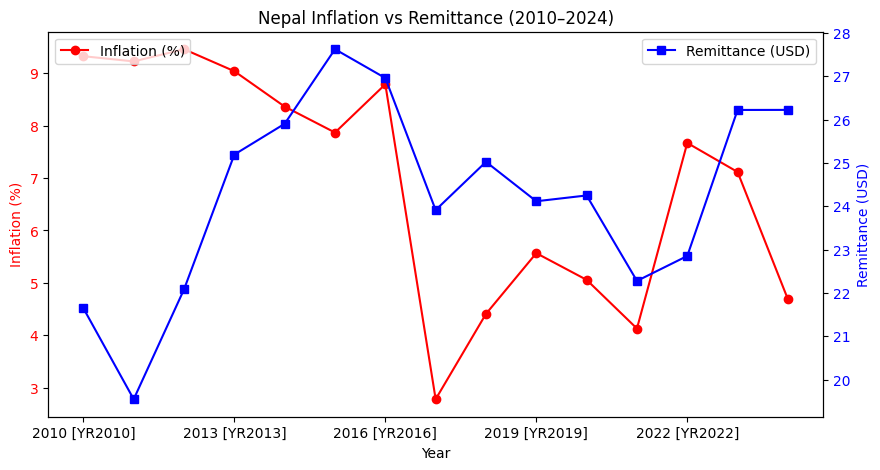

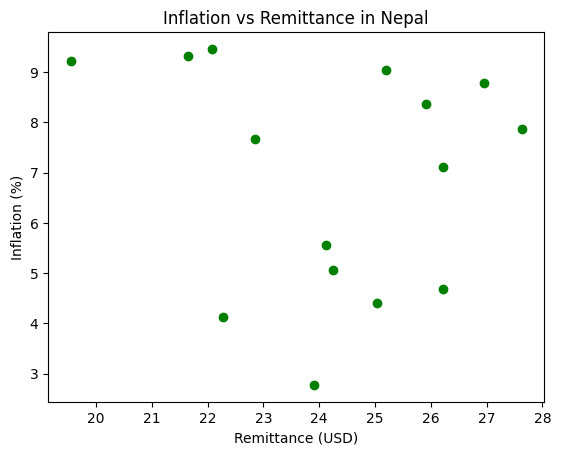

In [45]:

#Line plot:

fig, ax1 = plt.subplots(figsize=(10,5))


ax1.plot(years, inf_values, color="red", marker='o', label="Inflation (%)")
ax1.set_xlabel("Year")
ax1.set_ylabel("Inflation (%)", color="red")
ax1.tick_params(axis='y', labelcolor="red")
plt.xticks(years[::3]) 


ax2 = ax1.twinx()
ax2.plot(years, rem_values, color="blue", marker='s', label="Remittance (USD)")
ax2.set_ylabel("Remittance (USD)", color="blue")
ax2.tick_params(axis='y', labelcolor="blue")


plt.title("Nepal Inflation vs Remittance (2010–2024)")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.show()

#Scatter plot:

plt.scatter(rem_values, inf_values, color="green")
plt.xlabel("Remittance (USD)")
plt.ylabel("Inflation (%)")
plt.title("Inflation vs Remittance in Nepal")
plt.show()


## Key Insights
- Remittance inflows increased steadily after 2015
- Inflation spikes align with global economic shocks
- Weak correlation between inflation and remittance
- Nepal’s economy is highly dependent on remittances
